# Perform DE analysis

* Check purity levels

* Play around with LFC cut-offs for significance



<br>

<br>

Subset to:

* Intermediate risk

* Wilms only

* No ribo

* Look at death & relapse together



<br>


Select kernel: Single Cell R (4.3)

------

In [1]:
4+4

[1] 8

In [2]:
##### ----- Load libraries
requiredPackages <- c("edgeR","GSEABase", "data.table", "limma", "cowplot", "ggplot2", "dplyr","Matrix", "singscore") #"Manu",ggscireadxl

for (pkg in requiredPackages){
  suppressWarnings(suppressMessages(library(pkg, character.only = T)))
}

#### ----- Plotting functions

MDS2gg <- function(DGE_x, col_str,col_pal=NULL, shape_str=NULL, shape_pal=NULL){

 # col_title <- str_to_title(col_str)
  col_title <- col_str
  if (is.null(col_pal)){
    col_pal <- GetColPal(unique(as.vector(DGE_x$samples[[col_str]])))
  }

  if (!(is.null(shape_str))){

    shape_title <- shape_str
    if (is.null(shape_pal)){
      shape_pal <- getShapes(unique(as.vector(DGE_x$samples[[shape_str]])))
    }

    MDS_dat <- limma::plotMDS(cpm(DGE_x, log=TRUE, prior.count = 2),
                              col=as.vector(col_pal[as.vector(DGE_x$samples[[col_str]])]),
                              pch=as.vector(shape_pal[as.vector(DGE_x$samples[[shape_str]])]),
                              cex = 1.6, cex.lab=0.8, cex.axis=0.6, tck=-0.02,mgp = c(1.5, 0.3, 0), plot=FALSE)
    plot_dat <- data.frame(ColBy=as.vector(DGE_x$samples[[col_str]]),
                           ShapeBy=as.vector(DGE_x$samples[[shape_str]]),
                           Dim1=MDS_dat$x,
                           Dim2=MDS_dat$y)
    ggplot(data=plot_dat, aes(x=Dim1, y=Dim2, color=ColBy, shape=ShapeBy))+geom_point(size=4)+
      scale_color_manual(name=col_title, values=col_pal)+scale_shape_manual(name=shape_title,values=shape_pal)+theme_bw()+
      theme(panel.grid.minor = element_blank(),
            panel.grid.major = element_blank(),
            legend.direction = "vertical", legend.box = "vertical")
  } else {
    MDS_dat <- limma::plotMDS(cpm(DGE_x, log=TRUE, prior.count = 2),
                              col=as.vector(col_pal[as.vector(DGE_x$samples[[col_str]])]),
                              cex = 1.6, cex.lab=0.8, cex.axis=0.6, tck=-0.02,mgp = c(1.5, 0.3, 0), plot=FALSE)
    plot_dat <- data.frame(ColBy=as.vector(DGE_x$samples[[col_str]]),
                           Dim1=MDS_dat$x,
                           Dim2=MDS_dat$y)
    ggplot(data=plot_dat, aes(x=Dim1, y=Dim2, color=ColBy))+geom_point(size=4)+
      scale_color_manual(name=col_title, values=col_pal)+theme_bw()+
      theme(panel.grid.minor = element_blank(),
            panel.grid.major = element_blank(),
            legend.direction = "vertical", legend.box = "vertical")
  }

}

ggRLE <- function(dat_x, annot, col_str, col_pal=NULL, isLog=TRUE,isLarge=FALSE,
                  ylim = c(-2,2),zero_line=TRUE, zero_col="skyblue", medPoint=FALSE, whisk=1.5){
 # dat_x <- LEGO_DGE_lst$CLONE$counts
 # annot <- annot_x
  #col_title <- str_to_title(col_str)
  col_title <- col_str
  if (!(setequal(colnames(dat_x), rownames(annot)))){
    message("Make sure annot rownames match dat_x sample names")
  }

  if (!(isLog)){
    dat_x <- log2(dat_x+1)
  }

  if (is.null(col_pal)){
    col_pal <- GetColPal(unique(as.vector(annot[[col_str]])))
  }

  ## Subset to common sample names
  annot <- annot[order(as.vector(annot[[col_str]])), , drop = F]
  annot$ColourBy <- as.vector(annot[[col_str]])
  annot$Sample <- rownames(annot)
  dat_x <- dat_x[, rownames(annot)]

  ## RLE boxplots
  rle <- dat_x - rowMedians(dat_x)
  rleLong <- reshape2::melt(rle, value.name = "RLE", varnames = c("genes", "Sample"))
  rleLong$Sample <- as.character(rleLong$Sample)

  rleLong <- merge(data.table::data.table(rleLong),  # faster merging
                   data.table::data.table(annot),
                   by = "Sample", sort=F)

  ## Calculate the median of the RLE boxplots:
  rleLong <- rleLong %>%
    group_by(Sample) %>%
    mutate(MedRLE = median(RLE)) %>%
    ungroup() %>%
    data.frame()
  rleLong$Sample <- factor(rleLong$Sample , levels=unique(rleLong$Sample))

  ## Remove Whiskers of the boxplots if the sample size is very large -- Sep's code
  if(isLarge){
    whisk=0
  }

  if (medPoint){
    gg <- ggplot(rleLong, aes(x = Sample, y = RLE, fill = ColourBy))+
      stat_boxplot(geom = "errorbar", width = 0.3)+
      geom_boxplot(outlier.shape = NA, coef=whisk)+
      geom_point(data = rleLong[! duplicated(rleLong$Sample), ],
                 aes(x = Sample, y = MedRLE, fill = ColourBy),
                 size = 2, shape = 21, colour = "black", lwd = 2)+
      scale_fill_manual(name=col_title,values = col_pal)+
      scale_y_continuous(name = "RLE",limits = ylim)+theme_bw()+
      theme(panel.grid.minor = element_blank(),
          #  panel.grid.major = element_blank(),
            axis.ticks.x = element_blank(),
            axis.text.x = element_blank())
  } else {
    gg <- ggplot(rleLong, aes(x = Sample, y = RLE, fill = ColourBy))+
      stat_boxplot(geom = "errorbar", width = 0.3)+
      geom_boxplot(outlier.shape = NA,coef=whisk)+
      scale_fill_manual(name=col_title,values = col_pal)+
      scale_y_continuous(name = "RLE",limits = ylim)+theme_bw()+
      theme(panel.grid.minor = element_blank(),
          #  panel.grid.major = element_blank(),
            axis.ticks.x = element_blank(),
            axis.text.x = element_blank())
  }

  if (zero_line){
    gg <- gg + geom_hline(yintercept = 0, col = zero_col, lwd = 1)+
            theme(panel.grid.major=element_blank())
  }
  return(gg)
}

RLE2gg <- function(DGE_x, col_str, col_pal, geneLengths){

  if (is.na(geneLengths)){
    dat <- cpm(DGE_x, log=TRUE, prior.count = 1)
  } else {
    dat <- rpkm(DGE_x, log=TRUE, prior.count = 1, gene.length=geneLengths)
  }

  annot_x <- DGE_x$samples
  annot_x$Sample <- rownames(annot_x)
  # as.vector(DGE_x$samples[[col_str]])

  return(ggRLE(dat, annot_x, col_str, col_pal))

}


ggPCA <- function(dat_x, annot, col_str, col_pal=NULL,
                  shape_str=NULL, shape_pal=NULL,
                  IS_LOG=FALSE, CENTRE=TRUE,
                  SIZE=4, k=2, k_vec=c(1, 2), ...){

  if (!(setequal(colnames(dat_x), rownames(annot)))){
    message("Make sure annot rownames match dat_x sample names")
  }

  if (is.null(col_pal)){
    col_pal <- GetColPal(unique(as.vector(annot[[col_str]])))
  }

  ## Organise annotations
  annot$ColourBy <- as.vector(annot[[col_str]])
  annot$Sample <- rownames(annot)
  dat_x <- dat_x[, rownames(annot)]
  #col_title <- str_to_title(col_str)
  col_title <- col_str
    
  ## PCA
  PC_dat <- calc_pca(dat_x, is.log=IS_LOG, centre=CENTRE)

  ## Get plot data
  plot_dat <- as.data.frame(do.call(cbind,
                        lapply(1:k, function(x){PC_dat$sing.val$u[,x]})))
  colnames(plot_dat) <- paste0("PC", 1:k)
  plot_dat$Sample <- colnames(dat_x)

  plot_dat_merge <- merge(data.table::data.table(plot_dat),  # faster merging
                   data.table::data.table(annot),
                   by = "Sample", sort=F)

  if (k==2){
    k_x <- paste0("PC", k_vec[[1]])
    k_y <- paste0("PC", k_vec[[2]])
    plot_dat_merge$PC_x <- plot_dat_merge[[k_x]]
    plot_dat_merge$PC_y <-plot_dat_merge[[k_y]]

    if(!(is.null(shape_str))){
      plot_dat_merge$ShapeBy <- as.vector(plot_dat_merge[[shape_str]])
      #shape_title <- str_to_title(shape_str)
      shape_title <- shape_str
      if (is.null(shape_pal)){
        shape_pal <- getShapes(unique(as.vector(plot_dat_merge$ShapeBy)))
      }

      ggplot(plot_dat_merge, aes(x=PC_x, y=PC_y, colour=ColourBy, shape=ShapeBy))+geom_point(size=SIZE)+
        scale_color_manual(name=col_title, values=col_pal)+
        scale_shape_manual(name=shape_title,values=shape_pal)+theme_bw()+
        theme(panel.grid.minor = element_blank(),
              panel.grid.major = element_blank(),
              legend.direction = "vertical", legend.box = "vertical", ...)+
        labs(x=paste0(k_x," (", PC_dat$var[[k_vec[[1]]]],"%)"), y=paste0(k_y," (", PC_dat$var[[k_vec[[2]]]],"%)"))


    } else {
      ggplot(plot_dat_merge, aes(x=PC_x, y=PC_y, colour=ColourBy))+geom_point(size=SIZE)+
        scale_color_manual(name=col_title, values=col_pal)+theme_bw()+
        theme(panel.grid.minor = element_blank(),
              panel.grid.major = element_blank(),
              legend.direction = "vertical", legend.box = "vertical", ...)+
        labs(x=paste0(k_x," (", PC_dat$var[[k_vec[[1]]]],"%)"), y=paste0(k_y," (", PC_dat$var[[k_vec[[2]]]],"%)"))
    }


  } else {


    gg_dat <- reshape2::melt(plot_dat, value.name="weight", id.vars="Sample", variable.name="PC")

    all_combinations <- combn(as.vector(unique(gg_dat$PC)),2)
    plot_lst <- lapply(1:ncol(all_combinations), function(i){
      k_x <- all_combinations[1, i]
      k_y <- all_combinations[2, i]
      plot_dat_merge$PC_x <- plot_dat_merge[[k_x]]
      plot_dat_merge$PC_y <-plot_dat_merge[[k_y]]

      ggplot(plot_dat_merge, aes(x=PC_x, y=PC_y, colour=ColourBy))+geom_point(size=SIZE)+
        scale_color_manual(name=col_title, values=col_pal)+theme_bw()+
        theme(panel.grid.minor = element_blank(),
              panel.grid.major = element_blank(),
              legend.direction = "vertical", legend.box = "vertical", ...)+
        labs(x=k_x, y=k_y)
    })
    names(plot_lst) <- unlist(lapply(1:ncol(all_combinations), function(i){
      paste0(all_combinations[1, i],"_vs_",all_combinations[2, i])}))

    ### Co-ordinate grid so that descending row is PC1->
    plot_lst_rows <- lapply(1:(k-1), function(row_j){
      plot_lst[names(plot_lst)[grepl(paste0("PC", row_j,"_vs"),names(plot_lst))]]
      })

    ### Add NULL plots
    plot_rows <- c()
    for (x in 1:length(plot_lst_rows)){
      numbNull <- k-1-length(plot_lst_rows[[x]])
      if (numbNull > 0){
        plot_rows <- c(plot_rows,vector(mode = 'list', length = numbNull),plot_lst_rows[[x]])
      } else {
        plot_rows <- c(plot_rows,plot_lst_rows[[x]])
      }}

    ## Add legend to bottom right
    my_leg <- get_legend(plot_rows[[1]])
    n_leg <- length(plot_rows)-length(plot_lst_rows)+1

    ## And remove legends
    plot_rows <- lapply(plot_rows, function(plot_x){plot_x+theme(legend.position = "none")})

    ## Plot!
    return(cowplot::plot_grid(plotlist=plot_rows,
                              ncol=k-1, nrow=length(plot_lst_rows), byrow=TRUE))
  }

}

calc_pca <- function(data, is.log, centre) {

  if(is.log == TRUE){
    data <- data
  }else{
    data <- log2(data + 1)
  }
  svd <- svd(apply(data, 1, function(x) scale(x, scale = FALSE, center = centre)))
  percent <- svd$d^2/sum(svd$d^2)*100
  percent <- sapply(seq_along(percent), function(i) {round(percent[i], 2)})
  return(list(sing.val = svd, var = percent))

}

getShapes <- function(vec){

  n = length(vec)

  if (n <= 12){
    shapes <- c(19,15,17,18,23,25,22,21,24,8,4,3)
  } else {
    shapes <- 1:25
  }

  shapes <- shapes[1:n]
  names(shapes) <- vec
  return(shapes)
}


GetColPal <- function(vec){
  
  pal <- gg_color_hue(as.integer(length(vec)))
  names(pal) <- vec
  return(pal)
}


gg_color_hue <- function(n) {
  hues = seq(15, 360, length = n)
  hcl(h = hues, l = 65, c = 100)[1:n]
}

fig <- function(width, heigth){
 options(repr.plot.width = width, repr.plot.height = heigth)
 }


##### ----- Get directories
raw_data_path = "/lustre/scratch125/cellgen/behjati/jp40/pipelines/6_RNA/data/counts/"
data_save_dir = "/lustre/scratch125/cellgen/behjati/project_folders/wilms_EMSeq/output/rna/"
sample_sheet_dir = "/lustre/scratch125/cellgen/behjati/project_folders/wilms_EMSeq/metadata/"
                   
sample_sheet_df = read.table(paste0(sample_sheet_dir,"driver_and_manifest_table_2026_07_03_pm.csv"), sep=",", skip=1, header=TRUE)
                   
                   

<br>

<br>

## Load data & sample data

In [3]:
## -- Load data
counts_df <- read.table(paste0(data_save_dir, "combined_raw_counts.csv"), sep=",", header=TRUE,row.names=NULL)
counts_df <- counts_df[!grepl("^RP11-", counts_df$gene_name) &!grepl("^RPL", counts_df$gene_name),]

## -- Get library info
samples_r = read.table("ribozero.txt", sep="\t", header=FALSE)
samples_o = read.table("oligo.txt", sep="\t", header=FALSE)
missing_IDs <- setdiff(colnames(counts_df),c(samples_r$V1,samples_o$V1))
df_x = data.table(samples=c(samples_r$V1,samples_o$V1, missing_IDs),
          library=c(rep("ribo", length(samples_r$V1)), rep("oligo", length(samples_o$V1)), rep("NA", length(missing_IDs))))

## -- Get gene info
genes_df <- counts_df[,colnames(counts_df) %in% c("ensid", "gene_name"),]
rownames(genes_df) <- genes_df$ensid

## -- Prep data
rownames(counts_df) <- counts_df$ensid
counts_df <- counts_df[, !(colnames(counts_df) %in% c("ensid", "gene_name", "X"))]

## -- Get sample data
samples_df <- data.frame(sampleID = colnames(counts_df),
                                   library=as.vector(setNames(df_x$library, df_x$samples)[colnames(counts_df)]))

## -- Append more
cols_to_add <- c("Tumour.type", "Risk.category", "Event", "Outcome", "Outcome_qualifier", 
                 "sample_category", "Sample.type", "Age_at_diagnosis_months", "Sex", 
                 "Mets_at_ddx", "Predisposition", "Relapse_or_progression",
                "Event_free_survival", "Overall_survival", "Histology_of_this_specimen")

append_col <- function(col_x){return(as.vector(setNames(sample_sheet_df[[col_x]],
                                                  sample_sheet_df$RNA_ID)[colnames(counts_df)]))}

for (i in cols_to_add){
    samples_df[[i]] <- append_col(i)
}

## -- Add new group
x = samples_df[samples_df$Event %in% c("Relapse_alive", "Relapse_death"),]$sampleID
y = samples_df[samples_df$Outcome %in% c("Dead"),]$sampleID
z <- unique(c(x,y))
samples_df$all_outcome <- ifelse(samples_df$sampleID %in% z, "Bad", "Good")



In [4]:
## -- add purity
purity_df <- read.csv("/lustre/scratch125/cellgen/behjati/project_folders/wilms_EMSeq/metadata/purity_predisp.csv",
               header = TRUE, check.names = FALSE,stringsAsFactors = FALSE)

id_dict = setNames(sample_sheet_df$RNA_ID,sample_sheet_df$Sample)
purity_a_dict = setNames(purity_df$`Purity Estimate - ASCAT`, as.vector(id_dict[purity_df$DNA_ID]) )
purity_b_dict = setNames(purity_df$`Purity Estimate - Battenberg`, as.vector(id_dict[purity_df$DNA_ID]))

samples_df$purity <- as.vector(purity_a_dict[samples_df$sampleID])
samples_df$purity <- replace(samples_df$purity, samples_df$purity=="not_applicable", NA)
samples_df$purity  <- as.numeric(samples_df$purity)

Warning message:
“NAs introduced by coercion”


<br>

#### Subset samples

In [5]:
## -- Subset to Wilms
samples_df <- samples_df[samples_df$Tumour.type == "Wilms",]

## -- Exclude low risk
samples_df <- samples_df[!(samples_df$Risk.category %in% c("Low risk", "High risk")),]

## -- Remove ribo
samples_df <- samples_df[!(samples_df$library %in% c("ribo")),]

## -- Otherwise clean
samples_df <- samples_df[!(samples_df$Outcome== "unavailable"),]

samples_df <- samples_df[!(samples_df$Risk.category %in% c("Low risk", "High risk")),]
samples_df <- samples_df[!(samples_df$Histology_of_this_specimen %in% c("Nephroblastomatosis", "Blastemal", "Focal anaplasia")),]

## -- Remove low purity
samples_df <- samples_df[samples_df$purity > 0.6,]
samples_df <- samples_df[!(is.na(samples_df$purity)),]

## -- Subset
counts_df <- counts_df[,colnames(counts_df) %in% samples_df$sampleID]

In [6]:
table(paste0(samples_df$Histology_of_this_specimen,"_",samples_df$all_outcome))


                  Epithelial_Bad                  Epithelial_Good 
                               3                               39 
                       Mixed_Bad                       Mixed_Good 
                              17                              106 
 Non anaplastic and variants_Bad Non anaplastic and variants_Good 
                               4                               37 
                  Regressive_Bad                  Regressive_Good 
                              12                               70 
                     Stromal_Bad                     Stromal_Good 
                               8                               64 

<br>

### Make DGE object

In [85]:
## -- rows are genes, columns are samples
wilms_dge <- edgeR::DGEList(counts_df,
               group = samples_df$all_outcome,#$Outcome,
               samples = samples_df,
               genes=genes_df)
              

<br>

<br>

## Process counts

-----

<br>

#### Drop structural RNA/irrelevant/noisy genes

In [86]:
annot <- wilms_dge$genes[match(rownames(wilms_dge), wilms_dge$genes$ensid), ]
drop <- grepl("^MT-|^RPL|^RPS|^MRPL|^MRPS", annot$gene_name) |
        grepl("^RN7SK|^RN7SL|^RNU[0-9]|^RNVU|^SNOR|^SCARNA|^MIR[0-9]",
              annot$gene_name) |
        grepl("^RNA5S|^RNA18S|^RNA28S|^RMRP|^RPPH1", annot$gene_name)
cat("dropping", sum(drop), "structural / small RNA genes\n")
wilms_dge <- wilms_dge[!drop, ]

dropping 5687 structural / small RNA genes


#### Remove extreme library sizes

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


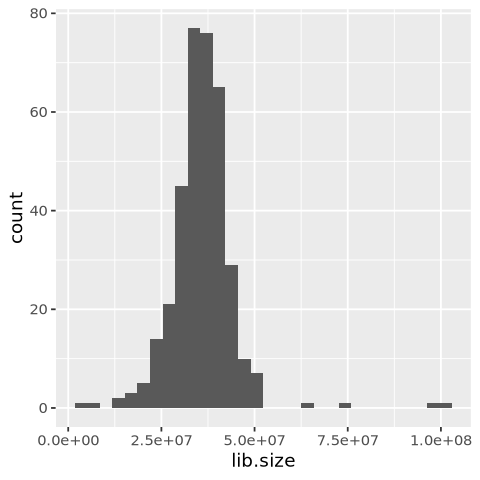

In [87]:
fig(4,4)
ggplot(data=wilms_dge$samples,aes(x=lib.size))+geom_histogram()

In [88]:
## -- minimum library size -- between 1 million and 100 million
wilms_dge <- wilms_dge[,(wilms_dge$samples$lib.size > 1e7) & (wilms_dge$samples$lib.size < 6e7) ] 

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


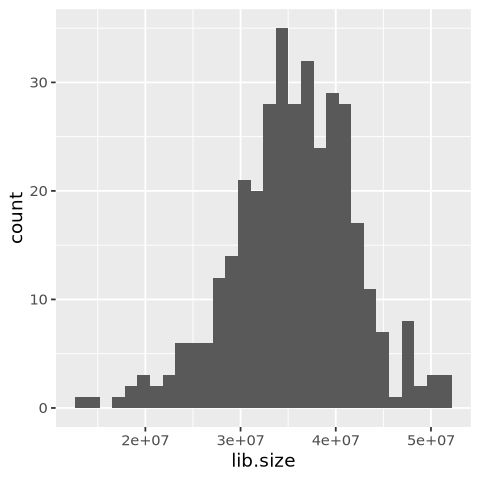

In [89]:
fig(4,4)
ggplot(data=wilms_dge$samples,aes(x=lib.size))+geom_histogram()

#### Gene filtering

keep
FALSE  TRUE 
14208 15117 


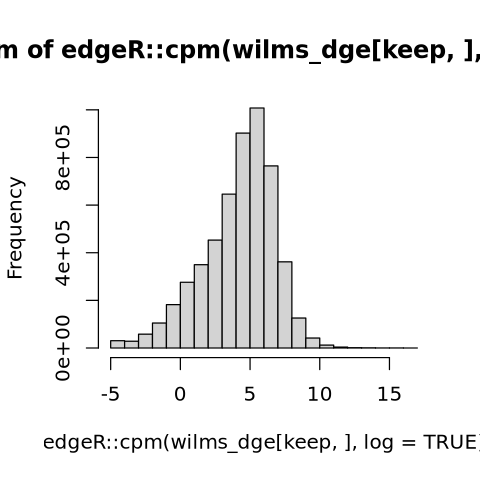

In [90]:
fig(4, 4)
keep = rowMeans(edgeR::cpm(y=wilms_dge, log = TRUE) >= 0.5) >= 0.2
#keep <- filterByExpr(wilms_dge)
hist(edgeR::cpm(wilms_dge[keep, ], log = TRUE))
print(table(keep))

In [91]:
wilms_dge <- wilms_dge[keep, ]

<br>

#### Make design matrix

After some samples have been dropped

In [92]:
## -- Design matrix
patient_factor <- as.factor(wilms_dge$samples$patientID)
group_factor <- as.factor(wilms_dge$samples$group)
other_factor <- as.factor(wilms_dge$samples$Histology_of_this_specimen)  # + Predisposition // Histology_of_this_specimen // Outcome
design_x <- model.matrix( ~0 +  group_factor + other_factor)
wilms_dge$design <- design_x

<br>

#### Processing

In [93]:
## -- Process counts
wilms_dge <- edgeR::calcNormFactors(wilms_dge, method="RLE")
wilms_dge$logCPM <- edgeR::cpm(wilms_dge, log=TRUE, prior.count = 1,
                             normalized.lib.sizes=TRUE, lib.size=wilms_dge$samples$lib.size)

## -- Estimate Dispersions
wilms_dge <- estimateDisp(wilms_dge, wilms_dge$design, robust=TRUE)

<br>

#### Save

In [108]:
saveRDS(wilms_dge, file =paste0(data_save_dir,"objects/", "wilms_dge.rds"))

<br>

<br>


## Perform DE

-----

In [95]:
head(wilms_dge$design)

,group_factorBad,group_factorGood,other_factorMixed,other_factorNon anaplastic and variants,other_factorRegressive,other_factorStromal
1,0,1,0,1,0,0
2,1,0,0,0,0,1
3,0,1,1,0,0,0
4,0,1,1,0,0,0
5,0,1,1,0,0,0
6,1,0,1,0,0,0


#### Fit & test

In [96]:
## -- Fit & test model to compare good vs bad outcome within intermediate only
fit_outcome <- glmQLFit(wilms_dge, wilms_dge$design, robust=TRUE)
fit_outcome <- glmQLFTest(fit_outcome, contrast=c(1,-1,0,0,0,0))
summary(decideTests(fit_outcome))

       1*group_factorBad -1*group_factorGood
Down                                     235
NotSig                                 14412
Up                                       470

#### Save DGEs

In [109]:
## Save only significant genes
tt_outcome <- topTags(fit_outcome, n=Inf, p.value=0.05, adjust.method = "BH", sort.by = "PValue")$table

write.table(tt_outcome,paste0(data_save_dir,"signatures/","GoodvsBad_Intermediate_DE_output.txt"),sep="\t",row.names=TRUE ) 


tt_outcome<br>

#### Look at genes

In [98]:
tt_outcome[(tt_outcome$logFC > 0) & (tt_outcome$gene_name %in% c("MYCN")),]

,ensid,gene_name,logFC,logCPM,F,PValue,FDR
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000134323,ENSG00000134323,MYCN,1.093309,5.38372,18.94968,1.76358e-05,0.003979111


In [99]:
tt_outcome[(tt_outcome$logFC > 0.5) & (tt_outcome$FDR < 0.05),]$gene_name

[1] "PDIK1L"        "SCD"           "DGAT2"         "FAM78B"       
  [5] "GPAM"          "FOXF1"         "KCNA5"         "MAPK8IP2"     
  [9] "CHI3L2"        "BMP5"          "KCNK17"        "OLFM1"        
 [13] "NMB"           "GPR63"         "ATP1A2"        "DLGAP2"       
 [17] "GABBR2"        "TMEM145"       "CPNE7"         "ANP32E"       
 [21] "STC2"          "XKR7"          "FASN"          "GLP1R"        
 [25] "PSAT1"         "FAM69C"        "ANKRD34B"      "CCDC102B"     
 [29] "TF"            "LPL"           "SLC14A1"       "CCNA1"        
 [33] "HIGD1B"        "COX4I2"        "ECEL1"         "ONECUT2"      
 [37] "C20orf195"     "SEMA5B"        "ATP5I"         "RUNDC3B"      
 [41] "SLCO1C1"       "BAI3"          "MYCN"          "FOXF2"        
 [45] "PLIN4"         "SSTR5"         "UCK2"          "ECE2"         
 [49] "C1orf51"       "ZIC1"          "GRIK3"         "LRTM2"        
 [53] "C2CD4C"        "MYB"           "MARC1"         "G0S2"         
 [57] "AP3B2"         "CLVS2"         "LIPE"          "ZDHHC11B"     
 [61] "NRARP"         "GALNT9"        "MACROD2"       "CRMP1"        
 [65] "NMNAT2"        "VSTM2B"        "ENC1"          "HEY1"         
 [69] "SP6"           "RPRM"          "GPRIN1"        "GNAZ"         
 [73] "CTSV"          "RHEBL1"        "LINC00176"     "INHBE"        
 [77] "RGS22"         "MAP7D2"        "S100A2"        "ENTPD2"       
 [81] "MEOX1"         "CABP1"         "ELAVL2"        "RGS17"        
 [85] "ZNF695"        "MGST1"         "APLP1"         "ESPN"         
 [89] "PCP4"          "PTCH1"         "ZNF703"        "LURAP1L"      
 [93] "CACNA1I"       "SYCP2"         "C12orf57"      "SLC6A20"      
 [97] "ESM1"          "HMGCLL1"       "DIRAS1"        "FAM72A"       
[101] "ADAMTS18"      "MPPED1"        "NMU"           "GPD1"         
[105] "MGAT5B"        "NME1"          "DDX52"         "MANEAL"       
[109] "FAT2"          "SH2D5"         "FAXC"          "GINS1"        
[113] "PRR7"          "FOXL1"         "KDM2B"         "ASPHD1"       
[117] "TCERG1L"       "PDZD7"         "GJA8"          "AC092198.1"   
[121] "DYDC2"         "KCNN3"         "FAM155B"       "ABCD2"        
[125] "LEFTY1"        "MZT2B"         "CSPG4"         "SEPT3"        
[129] "MESP1"         "TRIM36"        "LEMD1"         "AQP4"         
[133] "RP3-395M20.12" "CPNE4"         "CECR7"         "ELOVL4"       
[137] "GABRD"         "CNNM1"         "TMEM178B"      "PGF"          
[141] "PKP1"          "LINC00092"     "C10orf107"     "NGEF"         
[145] "PDZD4"         "COX20"         "RASD2"         "SFN"          
[149] "NUF2"          "KCNIP2"        "CCDC68"        "REEP1"        
[153] "SERPINA5"      "AC078941.1"    "INA"           "C11orf70"     
[157] "BTNL9"         "XRCC2"         "KCNH8"         "GPM6B"        
[161] "FZD10"         "MEGF11"        "FSD1"          "PRR18"        
[165] "SCUBE1"        "SYT12"         "BEND4"         "CCDC181"      
[169] "FAM57B"        "EFCAB1"        "SLITRK5"       "NRG2"         
[173] "TAL1"          "CDH24"         "FAM60A"        "SLC7A10"      
[177] "ETV4"          "RHBDL3"        "WASF3"         "PTPN14"       
[181] "GRIA1"         "LRRC16B"       "CDKN2B"        "C9orf171"     
[185] "NETO1"         "PLXNA2"        "MYEOV"         "KCNG3"        
[189] "LRRC55"        "LYPD1"         "C8orf88"       "LY6H"         
[193] "RAB39B"        "LRCOL1"        "TBX18"         "DAPL1"        
[197] "DLX1"          "DPYSL4"        "C17orf82"

In [100]:
tt_outcome[tt_outcome$logFC > 1& (tt_outcome$FDR < 0.05),]$gene_name

[1] "PDIK1L"     "SCD"        "DGAT2"      "FAM78B"     "FOXF1"     
 [6] "KCNA5"      "MAPK8IP2"   "CHI3L2"     "BMP5"       "KCNK17"    
[11] "OLFM1"      "ATP1A2"     "DLGAP2"     "GABBR2"     "TMEM145"   
[16] "CPNE7"      "XKR7"       "GLP1R"      "FAM69C"     "ANKRD34B"  
[21] "TF"         "LPL"        "SLC14A1"    "CCNA1"      "ECEL1"     
[26] "ONECUT2"    "C20orf195"  "ATP5I"      "RUNDC3B"    "SLCO1C1"   
[31] "BAI3"       "MYCN"       "FOXF2"      "PLIN4"      "SSTR5"     
[36] "ZIC1"       "GRIK3"      "LRTM2"      "G0S2"       "AP3B2"     
[41] "CLVS2"      "GALNT9"     "NMNAT2"     "VSTM2B"     "RPRM"      
[46] "MAP7D2"     "S100A2"     "ENTPD2"     "MEOX1"      "ELAVL2"    
[51] "ESPN"       "PCP4"       "SLC6A20"    "HMGCLL1"    "ADAMTS18"  
[56] "MPPED1"     "GPD1"       "FAT2"       "ASPHD1"     "TCERG1L"   
[61] "GJA8"       "AC092198.1" "FAM155B"    "LEFTY1"     "LEMD1"     
[66] "AQP4"       "CPNE4"      "CECR7"      "PKP1"       "SFN"       
[71] "SERPINA5"   "INA"        "MEGF11"     "BEND4"      "SLITRK5"   
[76] "GRIA1"      "NETO1"      "MYEOV"      "TBX18"      "DAPL1"     
[81] "DLX1"

In [101]:
tt_outcome[tt_outcome$logFC > 1.5,]$gene_name

[1] "SCD"      "DGAT2"    "FAM78B"   "FOXF1"    "KCNA5"    "CHI3L2"  
 [7] "BMP5"     "KCNK17"   "GABBR2"   "XKR7"     "GLP1R"    "FAM69C"  
[13] "ANKRD34B" "ECEL1"    "BAI3"     "FOXF2"    "PLIN4"    "ZIC1"    
[19] "LRTM2"    "CLVS2"    "S100A2"   "SERPINA5" "DLX1"

<br>

<br>

## Also assess raw logCPM difference

To avoid confounding histology effect too strongly.

We found that despite accounting for histology in the design matrix, the large hetergeneity across subtypes led to many histology group specific poor outcome genes. We performed wilcoxon rank tests to refine our module into a list of genes consistently and reliably higher in poor outcome patients, rather than being driven by outliers (To ensure rank separation).


-----

In [102]:
do_wilcox_test <- function(gene_str){

    gene_id = wilms_dge$genes[wilms_dge$genes$gene_name==gene_str,][["ensid"]]
    if (length(gene_id) > 1){
        gene_id = gene_id[1]
    }
    df_x = as.data.frame(wilms_dge$logCPM[gene_id,], col.names=c("logCPM"))
    df_x$Histology_of_this_specimen <- as.vector(setNames(wilms_dge$samples$Histology_of_this_specimen,wilms_dge$samples$sampleID)[rownames(df_x)])
    df_x$all_outcome <- as.vector(setNames(wilms_dge$samples$all_outcome,wilms_dge$samples$sampleID)[rownames(df_x)])
    df_x$logCPM <- df_x$`wilms_dge$logCPM[gene_id, ]`
    return(wilcox.test(df_x[df_x$all_outcome=="Good",]$logCPM,
                       df_x[df_x$all_outcome=="Bad",]$logCPM)$p.value)
}

## -- up
genes_to_test <- tt_outcome[(tt_outcome$logFC > 0.5) & (tt_outcome$FDR < 0.05),]$gene_name
p_val_lst = lapply(genes_to_test,do_wilcox_test)
pval_df = data.frame("pval"=as.vector(unlist(p_val_lst)), "gene_id"=genes_to_test)
genes_to_plot = pval_df[pval_df$pval<0.05,]$gene_id

## -- dn
genes_to_test <- tt_outcome[(tt_outcome$logFC < -0.5) & (tt_outcome$FDR < 0.05),]$gene_name
p_val_lst = lapply(genes_to_test,do_wilcox_test)
pval_df = data.frame("pval"=as.vector(unlist(p_val_lst)), "gene_id"=genes_to_test)
genes_to_plot_dn = pval_df[pval_df$pval<0.05,]$gene_id

In [103]:
length(genes_to_plot)

[1] 58

In [105]:
genes_to_plot

[1] "FAM78B"     "OLFM1"      "NMB"        "GPR63"      "ANP32E"    
 [6] "STC2"       "PSAT1"      "HIGD1B"     "ONECUT2"    "SEMA5B"    
[11] "ATP5I"      "RUNDC3B"    "BAI3"       "MYCN"       "UCK2"      
[16] "C1orf51"    "LRTM2"      "CRMP1"      "NMNAT2"     "VSTM2B"    
[21] "ENC1"       "HEY1"       "GNAZ"       "RGS22"      "ELAVL2"    
[26] "RGS17"      "ZNF695"     "MGST1"      "ZNF703"     "MPPED1"    
[31] "MGAT5B"     "FAXC"       "TCERG1L"    "AC092198.1" "FAM155B"   
[36] "CSPG4"      "TRIM36"     "ELOVL4"     "GABRD"      "CNNM1"     
[41] "TMEM178B"   "PKP1"       "C10orf107"  "NGEF"       "PDZD4"     
[46] "RASD2"      "C11orf70"   "KCNH8"      "FZD10"      "PRR18"     
[51] "CCDC181"    "SLITRK5"    "PTPN14"     "PLXNA2"     "KCNG3"     
[56] "LRRC55"     "C8orf88"    "TBX18"

In [106]:
genes_to_plot_dn

[1] "CTD-2376I4.2" "KMO"          "TMEM86A"      "FUCA1"        "SDC3"        
 [6] "DUSP8"        "LPXN"         "FOXP3"        "SMIM5"        "LTB"         
[11] "CXCL13"       "MAP3K8"       "TCN2"         "RASGEF1B"     "CD83"        
[16] "CAPG"         "TMEM52B"      "UCP2"         "IQGAP2"       "MS4A1"       
[21] "SLC38A6"      "CD38"         "ZC3H12A"      "PPP1R15A"     "HLA-DMA"     
[26] "PIK3CD"       "SGK1"         "CCL8"         "GMPR"         "CCIN"        
[31] "DHRS9"        "GLRX"         "ANGPTL7"      "RP1-78O14.1"  "HMGCS2"      
[36] "DAPP1"        "CD274"        "GBP1"         "GPX3"         "CXCR6"       
[41] "ODF3L1"       "ACAP1"        "CD160"        "IL18RAP"      "GPR114"      
[46] "SIRPG"        "SCML4"        "CCDC152"      "FDCSP"        "TMEM156"     
[51] "SMCO3"        "TNXB"         "PTGER2"       "MAP4K1"       "NFATC2"      
[56] "ERRFI1"       "MITF"         "FLVCR2"       "AC005618.6"   "NFKBIZ"      
[61] "GZMM"         "ACSM5"        "ABCA9"

<br>

#### Save!!

In [110]:
write.table(data.frame("UP_genes"=genes_to_plot),paste0(data_save_dir,"signatures/","Intermediate_DE_UP_genes.txt"),sep="\t",row.names=TRUE ) 
write.table(data.frame("DN_genes"=genes_to_plot_dn),paste0(data_save_dir,"signatures/","Intermediate_DE_DN_genes.txt"),sep="\t",row.names=TRUE ) 

other_dir="/nfs/users/nfs_h/hw12/WILMS/gene_sigs/"
write.table(data.frame("UP_genes"=genes_to_plot),paste0(other_dir,"Intermediate_DE_UP_genes.txt"),sep="\t",row.names=TRUE ) 
write.table(data.frame("DN_genes"=genes_to_plot_dn),paste0(other_dir,"Intermediate_DE_DN_genes.txt"),sep="\t",row.names=TRUE ) 
